In [1]:
import numpy as np
import pandas as pd

In [44]:
from config import data_path
def read_file(file_path):
    df = pd.read_csv(file_path)
    return df
read_file(data_path)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [45]:

df = pd.read_csv('Titanic.csv')
type(df)


pandas.core.frame.DataFrame

In [46]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [49]:
df.drop(['PassengerId','Name','Ticket'], axis =1 , inplace= True)

In [50]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [51]:
dtypes= df.dtypes
dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [52]:
nunique = df.nunique()
nunique


Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        248
Cabin       147
Embarked      3
dtype: int64

In [9]:
pd.DataFrame({'dtypes' : dtypes , 'nunique' : nunique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,int64,int64,object,float64,int64,int64,float64,object,object
nunique,2,3,2,88,7,7,248,147,3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


In [11]:
cat_cols = ["Survived", "Pclass", "Sex", "SibSp", "Parch", "Embarked" ]
df[cat_cols] = df[cat_cols].astype('category')


In [12]:
dtypes= df.dtypes
nunique = df.nunique()
pd.DataFrame({'dtypes' : dtypes , 'nunique' : nunique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,object,category
nunique,2,3,2,88,7,7,248,147,3


In [13]:
def get_type_info(df: pd.DataFrame)->pd.DataFrame :
    return pd.DataFrame({"dtypes" : df.dtypes , "nunique" : df.nunique()}).T

In [14]:
get_type_info(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
dtypes,category,category,category,float64,category,category,float64,object,category
nunique,2,3,2,88,7,7,248,147,3


In [15]:
df.select_dtypes("category")

,Survived,Pclass,Sex,SibSp,Parch,Embarked
0,0,3,male,1,0,S
1,1,1,female,1,0,C
2,1,3,female,0,0,S
3,1,1,female,1,0,S
4,0,3,male,0,0,S
...,...,...,...,...,...,...
886,0,2,male,0,0,S
887,1,1,female,0,0,S
888,0,3,female,1,2,S
889,1,1,male,0,0,C


In [16]:
null = df.isnull().sum()
raito = null / 891 * 100
raito

Survived     0.000000
Pclass       0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [17]:
df = df.dropna(subset=["Embarked"])

In [18]:
df = df.drop("Cabin", axis=1)

In [19]:
df.describe()


,Age,Fare
count,712.000000,889.000000
mean,29.642093,32.096681
std,14.492933,49.697504
min,0.420000,0.000000
25%,20.000000,7.895800
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [20]:
median = df["Age"].median()
df["Age"] = df["Age"].fillna(median)

In [21]:
null = df.isnull().sum()
raito = null / 891 * 100
raito

Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
SibSp       0.0
Parch       0.0
Fare        0.0
Embarked    0.0
dtype: float64

In [22]:
num_cols = df.select_dtypes("number").columns
num_cols

Index(['Age', 'Fare'], dtype='object')

In [23]:
fences = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
   # print(lower_fence,"*******", upper_fence)
    
    fences.append([col, lower_fence, upper_fence])
    
result = pd.DataFrame(
        fences, 
        columns=["column","lower_fence", "upper_fence"]
        )
display(result)

,column,lower_fence,upper_fence
0,Age,2.5000,54.5000
1,Fare,-26.7605,65.6563


In [24]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    lower_outliers = df[ df[col] < lower_fence ][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    
    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)
    
    
    #print(lower_outliers)
    #print(upper_outliers)
     

In [25]:
pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:
pip install seaborn



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

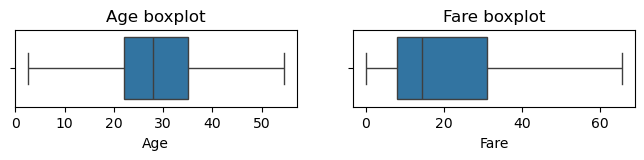

In [28]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
    

In [29]:
def replace_outliers(df):
    for col in num_cols:
    
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
    
        IQR = Q3 - Q1
    
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower_fence, upper_fence)
    
    return df  

In [30]:
df = replace_outliers(df)


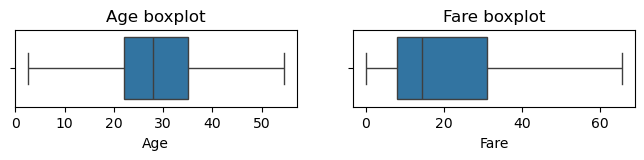

In [31]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} boxplot")
    

In [32]:
def handle_outliers(df, algo = "IQR", treatment = "clip", multiplier = 1.5):
    
    pass

In [33]:
df.drop_duplicates(inplace=True)

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
def remove_duplicates(df, subset_col=None, keep_strategy='first'):
    
    return df.drop_duplicates(subset=subset_col, keep=keep_strategy).reset_index(drop=True)


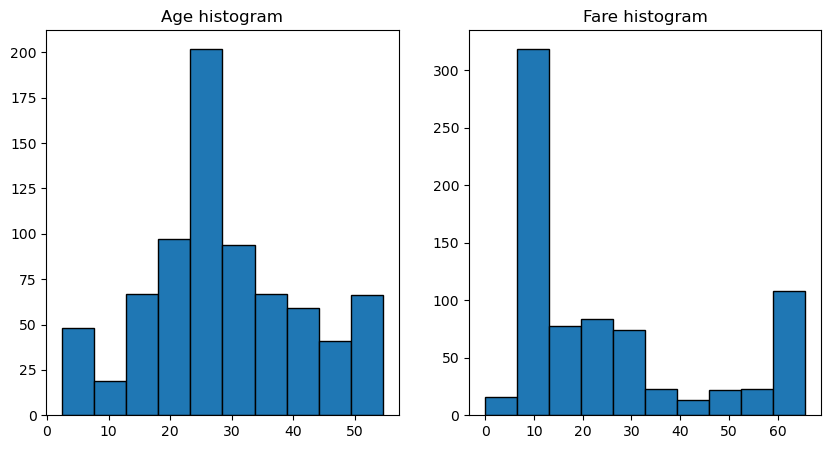

In [36]:
plt.figure(figsize=(10,5))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    plt.hist(df[col], edgecolor='black' )
    plt.title(f"{col} histogram")
    
plt.show()    

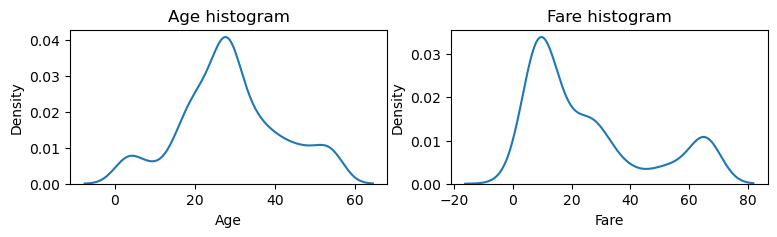

In [37]:
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1 , 2 , i+1)
    sns.kdeplot(df[col] )
    plt.title(f"{col} histogram")
    
plt.show()    

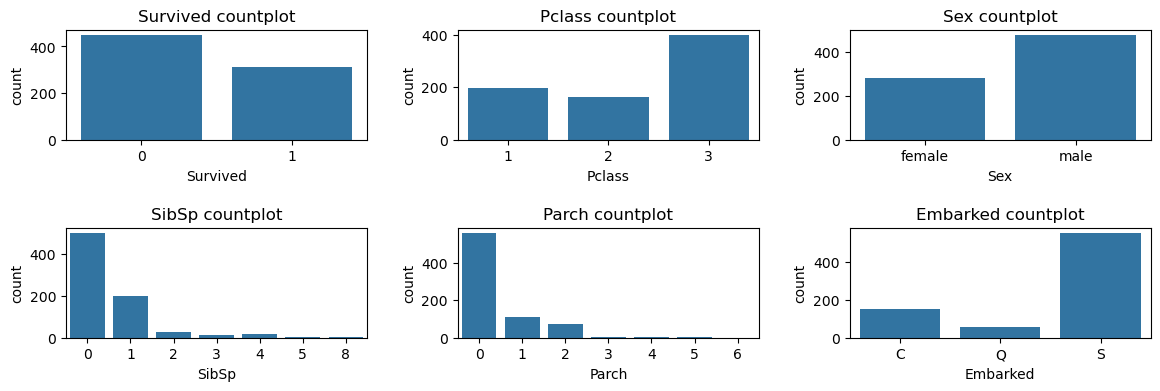

In [38]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    sns.countplot(x = col, data=df)
    plt.title(f"{col} countplot")
plt.subplots_adjust(hspace=0.8, wspace=0.3)    
plt.show()

In [39]:
unique=df["Survived"].value_counts()
counts = unique.values
category_names = unique.index
category_names

CategoricalIndex([0, 1], categories=[0, 1], ordered=False, dtype='category', name='Survived')

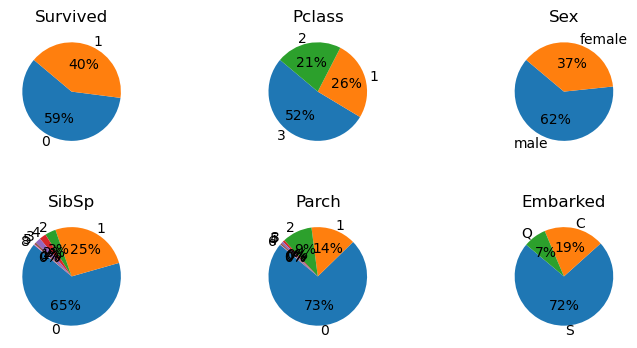

In [40]:
plt.figure(figsize=(9,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique=df[col].value_counts()
    counts = unique.values  
    category_names = unique.index
    plt.pie(counts, labels=category_names, startangle=140, autopct='%1.1d%%')
    plt.title(f"{col}")
    plt.subplots_adjust(hspace=0.5, wspace=0.2)
 
plt.show()    
    

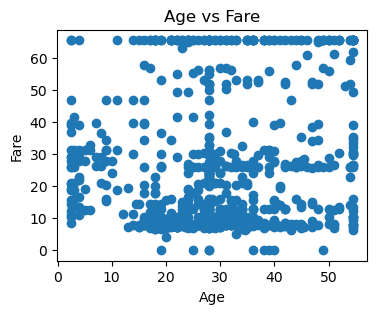

In [41]:
plt.figure(figsize=(4,3))
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

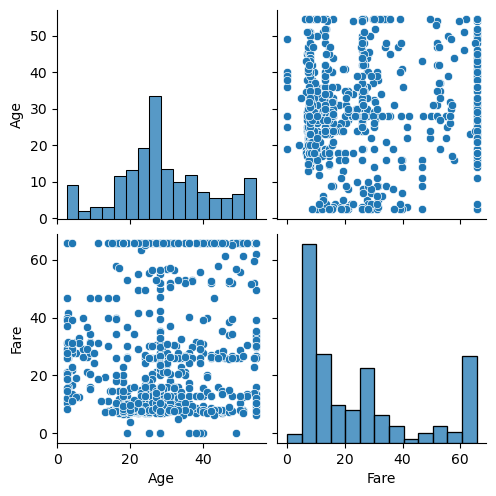

In [42]:
sns.pairplot(df)

<Axes: >

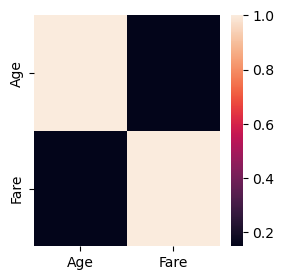

In [43]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(3,3))
sns.heatmap(corr)